In [1]:
%load_ext autoreload
%autoreload 2

# LoRA-Laplace Training Pipeline

Full pipeline for the LoRA + diagonal Laplace Approximation uncertainty backend:

1. **Configuration** — paths, model, hyperparameters
2. **Fine-tune** — train LoRA adapters on (source, summary) pairs
3. **Fit Laplace approximation** — compute diagonal Fisher information and posterior variance
4. **Score calibration corpus** — collect sentence-level uncertainty scores
5. **Fit quantile normalizer** — map raw epistemic MI to a 0–100 display scale
6. **Upload to HuggingFace Hub** — push adapter, sampler and quantile config

All heavy-lifting is done by `src.lora_training` and `src.lora_laplace_backend` — this notebook only sets parameters and calls those modules.

**Input**: `data/summaries_v4.jsonl` (produced by `01_data_ingestion.ipynb`)

## 1. Configuration

In [5]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = ROOT / "data"
MODELS_DIR = ROOT / "models"
CONFIG_DIR = ROOT / "config"
MODELS_DIR.mkdir(exist_ok=True)

SUMMARIES_FILE             = DATA_DIR / "summaries_v4.jsonl"
ADAPTER_DIR                = MODELS_DIR / "bart-large-xsum-lora"
SCORES_FILE                = DATA_DIR / "uncertainty_scores_lora_laplace.jsonl"
SAMPLER_FILE               = ADAPTER_DIR / "laplace_sampler.npz"
QUANTILES_FILE             = CONFIG_DIR / "uncertainty_quantiles_lora_laplace.json"
AMBIGUITY_QUANTILES_FILE   = CONFIG_DIR / "ambiguity_quantiles_lora_laplace.json"
CONSISTENCY_QUANTILES_FILE = CONFIG_DIR / "consistency_quantiles_lora_laplace.json"

# ── Model ─────────────────────────────────────────────────────────────────────
BASE_MODEL = "facebook/bart-large-xsum"

# ── LoRA hyperparameters ──────────────────────────────────────────────────────
LORA_RANK           = 8
LORA_ALPHA          = 16
LORA_DROPOUT        = 0.1
LORA_TARGET_MODULES = ["q_proj", "v_proj"]
LORA_LAYERS        = [10, 11]   # last 2 decoder layers (0-based, out of 12)

# ── Training hyperparameters ──────────────────────────────────────────────────
EPOCHS        = 5
BATCH_SIZE    = 4
GRAD_ACCUM    = 4
LEARNING_RATE = 5e-4 # 3e-4
VAL_SPLIT     = 0.1
MAX_SRC_LEN   = 512
MAX_TGT_LEN   = 128
SEED          = 42
BF16          = True   # set False if bf16 is not supported on your device

# ── Laplace calibration ───────────────────────────────────────────────────────
CALIBRATION_SPLIT = 0.1
PRIOR_PRECISION   = 1.0
# Rescale posterior_std so its mean equals TARGET_STD.  The diagonal Fisher is
# typically dominated by the isotropic prior (F_ii << lambda), so the raw
# posterior_std ≈ 1/sqrt(lambda) ≈ 1.0 for all parameters regardless of data.
# This far exceeds typical LoRA weight magnitudes (~0.02-0.04) and collapses
# per-sentence MI to near-zero.  TARGET_STD=0.1 was found empirically to
# maximise per-sentence spread while keeping perturbations in a plausible range.
TARGET_STD           = 0.1
SAMPLE_COUNT         = 5  # must match the production API default (ScoreRequest.sample_count)
SCORING_PAIRS_LIMIT  = 500  # set to None to use all pairs (much slower)

# ── HuggingFace Hub ───────────────────────────────────────────────────────────
HF_REPO_ID   = "rdisipio/summarizer-uncertainty-models"
HF_SUBFOLDER = "bart-large-xsum-lora-laplace"

print("Config OK")

Config OK


## 2. Load and split data

In [2]:
from src.lora_training import load_pairs, split_pairs

pairs = load_pairs(str(SUMMARIES_FILE))
train_pairs, val_pairs = split_pairs(pairs, val_split=VAL_SPLIT, seed=SEED)
print(f"Train: {len(train_pairs)}  |  Val: {len(val_pairs)}")

Train: 8098  |  Val: 899


## 3. Fine-tune with LoRA

In [21]:
import numpy as np, torch
from src.lora_training import build_lora_model, train_lora

torch.manual_seed(SEED)
np.random.seed(SEED)

model, tokenizer = build_lora_model(
    model_name=BASE_MODEL,
    lora_rank=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    layers_to_transform=LORA_LAYERS,
    layers_pattern="decoder",
)

train_lora(
    model=model,
    tokenizer=tokenizer,
    train_pairs=train_pairs,
    val_pairs=val_pairs,
    output_dir=str(ADAPTER_DIR),
    max_source_length=MAX_SRC_LEN,
    max_target_length=MAX_TGT_LEN,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    bf16=BF16,
    seed=SEED,
)

Loading weights:   0%|          | 0/513 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


trainable params: 131,072 || all params: 509,362,176 || trainable%: 0.0257


Tokenising train set:   0%|          | 0/8098 [00:00<?, ? examples/s]

Tokenising validation set:   0%|          | 0/899 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/Users/disipio/.local/share/virtualenvs/summarizer-uncertainty-ml-lNq8rFAG/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,8.287250,2.005708
2,8.036350,1.952303
3,7.832620,1.919474
4,7.722778,1.921350
5,7.724123,1.915871


/Users/disipio/.local/share/virtualenvs/summarizer-uncertainty-ml-lNq8rFAG/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/disipio/.local/share/virtualenvs/summarizer-uncertainty-ml-lNq8rFAG/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/disipio/.local/share/virtualenvs/summarizer-uncertainty-ml-lNq8rFAG/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/disipio/.local/share/virtualenvs/summarizer-uncertainty-ml-lNq8rFAG/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning

## 4. Fit the diagonal Laplace approximation

In [ ]:
import random
from peft import PeftModel
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from src.lora_laplace_backend import (
    LoraLaplaceBackend,
    DiagonalLaplacePosteriorSampler,
    fit_laplace_approximation,
    save_laplace_sampler,
)
from src.lora_training import load_pairs

# Re-load all pairs and carve out the calibration subset
all_pairs = [(r["source"], r["target"]) for r in load_pairs(str(SUMMARIES_FILE))]
random.seed(SEED)
random.shuffle(all_pairs)
cal_size = max(1, int(len(all_pairs) * CALIBRATION_SPLIT))
calibration_data = all_pairs[:cal_size]
print(f"Calibration samples: {len(calibration_data)}")

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

base = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)
peft_model = PeftModel.from_pretrained(base, str(ADAPTER_DIR), is_trainable=True)
tok = AutoTokenizer.from_pretrained(BASE_MODEL)

backend = LoraLaplaceBackend(peft_model=peft_model, tokenizer=tok, device=device)

print("Fitting Laplace approximation...")
sampler = fit_laplace_approximation(
    backend=backend,
    calibration_data=calibration_data,
    prior_precision=PRIOR_PRECISION,
)

# Rescale posterior_std to target mean magnitude.
# The raw Fisher diagonal is dominated by the prior (F_ii << lambda), so the
# sampler's posterior_std ≈ 1.0 uniformly — far larger than LoRA weight
# magnitudes (~0.02-0.04).  Uniform rescaling to TARGET_STD preserves the
# relative structure of the posterior while keeping perturbations meaningful.
current_std = sampler._posterior_std
scale = TARGET_STD / float(current_std.mean())
rescaled_variance = (current_std * scale) ** 2
sampler = DiagonalLaplacePosteriorSampler(
    param_names=sampler._param_names,
    param_shapes=sampler._param_shapes,
    posterior_variance=rescaled_variance,
)
print(f"Posterior std rescaled: mean={float(sampler._posterior_std.mean()):.4f} (target={TARGET_STD})")

save_laplace_sampler(sampler, str(SAMPLER_FILE))
print(f"Sampler saved to {SAMPLER_FILE}")

## 5. Score the corpus and collect uncertainty values

In [6]:
# ── Reload backend and sampler from disk (skip if section 4 was just run) ────
# Run this cell if the kernel was restarted and backend/sampler are not in memory.
import torch
from peft import PeftModel
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from src.lora_laplace_backend import LoraLaplaceBackend, load_laplace_sampler
from src.lora_training import load_pairs
import random

if "backend" not in dir() or "sampler" not in dir():
    device = (
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )
    print(f"Reloading backend from {ADAPTER_DIR} on {device}...")
    base = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)
    peft_model = PeftModel.from_pretrained(base, str(ADAPTER_DIR), is_trainable=True)
    tok = AutoTokenizer.from_pretrained(BASE_MODEL)
    backend = LoraLaplaceBackend(peft_model=peft_model, tokenizer=tok, device=device)
    print(f"Reloading sampler from {SAMPLER_FILE}...")
    sampler = load_laplace_sampler(str(SAMPLER_FILE))

# Rebuild scoring_pairs and all_pairs regardless (cheap — just reads JSONL)
all_pairs = [(r["source"], r["target"]) for r in load_pairs(str(SUMMARIES_FILE))]
random.seed(SEED)
random.shuffle(all_pairs)
cal_size = max(1, int(len(all_pairs) * CALIBRATION_SPLIT))
scoring_pairs = all_pairs[cal_size:]
print(f"Ready. {len(scoring_pairs)} pairs to score. Base model: {BASE_MODEL}, LoRA adapter: {ADAPTER_DIR.name}")

Ready. 8098 pairs to score. Base model: facebook/bart-large-xsum, LoRA adapter: bart-large-xsum-lora


In [7]:
from tqdm.auto import tqdm
from src.scorer import SummaryUncertaintyScorer
from src.data_pipeline import write_jsonl

scorer = SummaryUncertaintyScorer(backend=backend, posterior_sampler=sampler)
scoring_pairs = all_pairs[cal_size:]
if SCORING_PAIRS_LIMIT is not None:
    scoring_pairs = scoring_pairs[:SCORING_PAIRS_LIMIT]
print(f"Scoring {len(scoring_pairs)} pairs with sample_count={SAMPLE_COUNT} (production default)")

all_sentence_scores = []
skipped = 0

SCORES_FILE.unlink(missing_ok=True)
for source, summary in tqdm(scoring_pairs, desc="Scoring"):
    try:
        result = scorer.score_summary(source=source, summary=summary,
                                      sample_count=SAMPLE_COUNT, seed=SEED)
    except Exception as e:
        print(f"[ERROR] {e}")
        skipped += 1
        continue

    sentence_scores = [
        {"sentence_index": s.sentence_index, "sentence_text": s.sentence_text,
         "uncertainty": s.uncertainty, "expected_entropy": s.expected_entropy,
         "mean_logprob": s.mean_logprob}
        for s in result.sentence_results
    ]
    all_sentence_scores.extend(sentence_scores)
    if sentence_scores:
        avg = sum(s["uncertainty"] for s in sentence_scores) / len(sentence_scores)
        write_jsonl(str(SCORES_FILE), {"sentence_scores": sentence_scores, "uncertainty_avg": avg})

print(f"Scored {len(scoring_pairs) - skipped} summaries, {len(all_sentence_scores)} sentences. Skipped: {skipped}")

Scoring 500 pairs with sample_count=5 (production default)


Scoring:   0%|          | 0/500 [00:00<?, ?it/s]

Scored 500 summaries, 1342 sentences. Skipped: 0


## 6. Fit quantile normalizer

Sentences: 1342  |  Boundaries: ['0.5970', '1.0798', '1.1331', '1.1806', '1.2991']


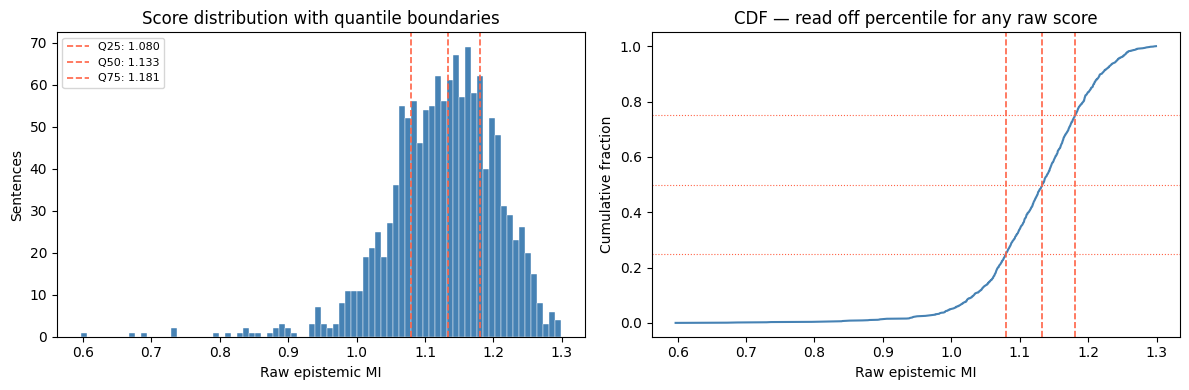

In [8]:
import matplotlib.pyplot as plt
from src.lora_training import fit_quantiles, save_quantiles

uncertainty_scores_raw = [s["uncertainty"] for s in all_sentence_scores if s.get("uncertainty") is not None]
uncertainty_boundaries = fit_quantiles(uncertainty_scores_raw)

QUANTILES_FILE.parent.mkdir(parents=True, exist_ok=True)
save_quantiles(uncertainty_boundaries, str(QUANTILES_FILE))

scores = sorted(uncertainty_scores_raw)
n = len(scores)
print(f"Sentences: {n}  |  Boundaries: {[f'{b:.4f}' for b in uncertainty_boundaries]}")

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(scores, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
for q, b in zip([25, 50, 75], uncertainty_boundaries[1:-1]):
    axes[0].axvline(b, color="tomato", linestyle="--", linewidth=1.2, label=f"Q{q}: {b:.3f}")
axes[0].set_xlabel("Raw epistemic MI")
axes[0].set_ylabel("Sentences")
axes[0].set_title("Score distribution with quantile boundaries")
axes[0].legend(fontsize=8)

cdf_y = [i / (n - 1) for i in range(n)]
axes[1].plot(scores, cdf_y, color="steelblue", linewidth=1.5)
for q, b in zip([0.25, 0.50, 0.75], uncertainty_boundaries[1:-1]):
    axes[1].axvline(b, color="tomato", linestyle="--", linewidth=1.2)
    axes[1].axhline(q, color="tomato", linestyle=":", linewidth=0.8)
axes[1].set_xlabel("Raw epistemic MI")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("CDF — read off percentile for any raw score")

plt.tight_layout()
plt.show()

### 6b. Fit ambiguity quantile normalizer

`ambiguity_score` is derived from `expected_entropy` — the average within-sample token entropy.
It captures linguistic vagueness intrinsic to the text, independent of model parameter uncertainty.

Sentences: 1342  |  Boundaries: ['2.0372', '4.2226', '4.7223', '5.1787', '6.2946']


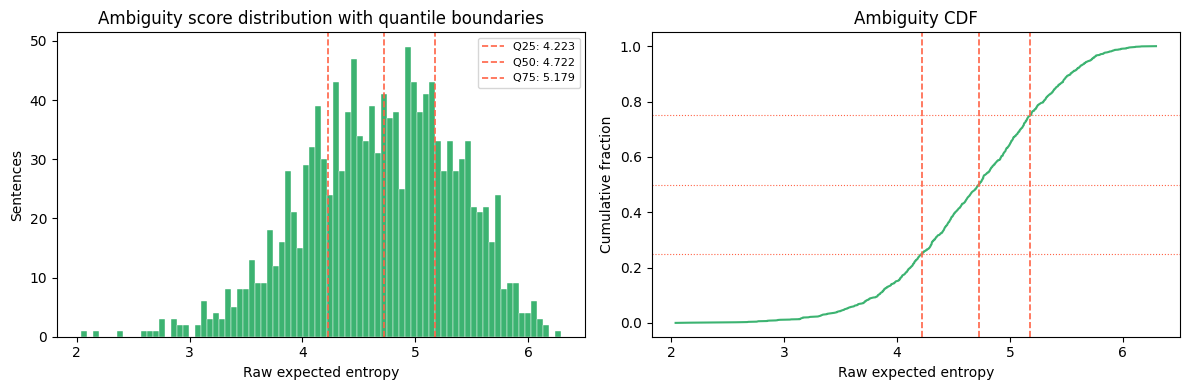

In [9]:
from src.lora_training import fit_quantiles, save_quantiles
from src.data_pipeline import read_jsonl

if "all_sentence_scores" not in dir() or not all_sentence_scores:
    print(f"all_sentence_scores not in memory — loading from {SCORES_FILE}")
    all_sentence_scores = [
        s for record in read_jsonl(str(SCORES_FILE)) for s in record.get("sentence_scores", [])
    ]
    print(f"Loaded {len(all_sentence_scores)} sentence scores from disk")

ambiguity_scores_raw = [s["expected_entropy"] for s in all_sentence_scores if s.get("expected_entropy") is not None]
if not ambiguity_scores_raw:
    raise RuntimeError(
        "No expected_entropy values found. Re-run section 5 — the scoring cell now saves this field."
    )

ambiguity_scores = sorted(ambiguity_scores_raw)
n_amb = len(ambiguity_scores)
ambiguity_boundaries = fit_quantiles(ambiguity_scores)

save_quantiles(ambiguity_boundaries, str(AMBIGUITY_QUANTILES_FILE))
print(f"Sentences: {n_amb}  |  Boundaries: {[f'{b:.4f}' for b in ambiguity_boundaries]}")

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ambiguity_scores, bins=80, color="mediumseagreen", edgecolor="white", linewidth=0.3)
for q, b in zip([25, 50, 75], ambiguity_boundaries[1:-1]):
    axes[0].axvline(b, color="tomato", linestyle="--", linewidth=1.2, label=f"Q{q}: {b:.3f}")
axes[0].set_xlabel("Raw expected entropy")
axes[0].set_ylabel("Sentences")
axes[0].set_title("Ambiguity score distribution with quantile boundaries")
axes[0].legend(fontsize=8)

cdf_y = [i / (n_amb - 1) for i in range(n_amb)]
axes[1].plot(ambiguity_scores, cdf_y, color="mediumseagreen", linewidth=1.5)
for q, b in zip([0.25, 0.50, 0.75], ambiguity_boundaries[1:-1]):
    axes[1].axvline(b, color="tomato", linestyle="--", linewidth=1.2)
    axes[1].axhline(q, color="tomato", linestyle=":", linewidth=0.8)
axes[1].set_xlabel("Raw expected entropy")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Ambiguity CDF")

plt.tight_layout()
plt.show()

### 6c. Fit consistency quantile normalizer

`consistency_score` is derived from `mean_logprob` — the average log-probability the model assigns to the summary tokens given the source.  A low `mean_logprob` means the model would not naturally generate this summary from this source, which is a signal of source/summary mismatch.

The raw value used for normalisation is `-mean_logprob` (positive; higher = less consistent).  The display score is then inverted so that **higher score = more consistent**.

Sentences: 1342  |  Boundaries: ['6.1245', '7.8752', '8.8008', '9.8231', '17.9864']


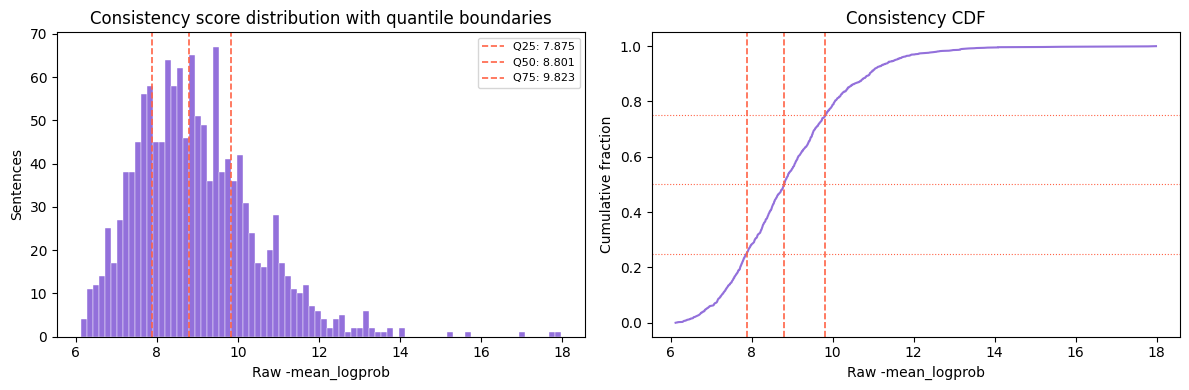

In [10]:
from src.lora_training import fit_quantiles, save_quantiles
from src.data_pipeline import read_jsonl

if "all_sentence_scores" not in dir() or not all_sentence_scores:
    print(f"all_sentence_scores not in memory — loading from {SCORES_FILE}")
    all_sentence_scores = [
        s for record in read_jsonl(str(SCORES_FILE)) for s in record.get("sentence_scores", [])
    ]
    print(f"Loaded {len(all_sentence_scores)} sentence scores from disk")

raw_logprobs = [s["mean_logprob"] for s in all_sentence_scores if s.get("mean_logprob") is not None]
if not raw_logprobs:
    raise RuntimeError(
        "No mean_logprob values found. Re-run section 5 — the scoring cell now saves this field."
    )

# Negate so higher value = less consistent; fit quantile boundaries on this scale.
inconsistency_scores = sorted(-lp for lp in raw_logprobs)
n_con = len(inconsistency_scores)
consistency_boundaries = fit_quantiles(inconsistency_scores)

save_quantiles(consistency_boundaries, str(CONSISTENCY_QUANTILES_FILE))
print(f"Sentences: {n_con}  |  Boundaries: {[f'{b:.4f}' for b in consistency_boundaries]}")

# ── Distribution plot ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(inconsistency_scores, bins=80, color="mediumpurple", edgecolor="white", linewidth=0.3)
for q, b in zip([25, 50, 75], consistency_boundaries[1:-1]):
    axes[0].axvline(b, color="tomato", linestyle="--", linewidth=1.2, label=f"Q{q}: {b:.3f}")
axes[0].set_xlabel("Raw -mean_logprob")
axes[0].set_ylabel("Sentences")
axes[0].set_title("Consistency score distribution with quantile boundaries")
axes[0].legend(fontsize=8)

cdf_y = [i / (n_con - 1) for i in range(n_con)]
axes[1].plot(inconsistency_scores, cdf_y, color="mediumpurple", linewidth=1.5)
for q, b in zip([0.25, 0.50, 0.75], consistency_boundaries[1:-1]):
    axes[1].axvline(b, color="tomato", linestyle="--", linewidth=1.2)
    axes[1].axhline(q, color="tomato", linestyle=":", linewidth=0.8)
axes[1].set_xlabel("Raw -mean_logprob")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Consistency CDF")

plt.tight_layout()
plt.show()

## 7. Upload to HuggingFace Hub

In [11]:
from src.lora_training import upload_to_hub

upload_to_hub(
    files=[
        (str(ADAPTER_DIR / "adapter_config.json"),       f"{HF_SUBFOLDER}/adapter_config.json"),
        (str(ADAPTER_DIR / "adapter_model.safetensors"), f"{HF_SUBFOLDER}/adapter_model.safetensors"),
        (str(ADAPTER_DIR / "tokenizer.json"),            f"{HF_SUBFOLDER}/tokenizer.json"),
        (str(ADAPTER_DIR / "tokenizer_config.json"),     f"{HF_SUBFOLDER}/tokenizer_config.json"),
        (str(SAMPLER_FILE),                              f"{HF_SUBFOLDER}/laplace_sampler.npz"),
        (str(QUANTILES_FILE),                            f"{HF_SUBFOLDER}/uncertainty_quantiles_lora_laplace.json"),
        (str(AMBIGUITY_QUANTILES_FILE),                  f"{HF_SUBFOLDER}/ambiguity_quantiles_lora_laplace.json"),
        (str(CONSISTENCY_QUANTILES_FILE),                f"{HF_SUBFOLDER}/consistency_quantiles_lora_laplace.json"),
    ],
    repo_id=HF_REPO_ID,
)

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


In [40]:
from src.scorer import SummaryUncertaintyScorer

scorer = SummaryUncertaintyScorer(backend=backend, posterior_sampler=sampler)
source, summary = all_pairs[0]

In [41]:
for k in [None, 5]:
    result = scorer.score_summary(source=source, summary=summary, sample_count=20, seed=SEED, top_k_tokens=k)
    print(f"\n--- top_k_tokens={k} ---")
    for s in result.sentence_results:
        print(f"  [{s.uncertainty:.4f}] {s.sentence_text[:80]}")



--- top_k_tokens=None ---
  [0.5408] So, the EU job market is pretty stable, and people there are less open to wage c
  [0.5291] Back in the '90s, many Americans didn’t even know what globalization was, but it
  [0.5224] Interestingly, support for globalization has dropped significantly, especially a

--- top_k_tokens=5 ---
  [0.7634] So, the EU job market is pretty stable, and people there are less open to wage c
  [0.7194] Back in the '90s, many Americans didn’t even know what globalization was, but it
  [0.6511] Interestingly, support for globalization has dropped significantly, especially a
